In [17]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering 
%matplotlib inline

We use iris flower dataset to test the heirarchical clustering 


In [18]:
from sklearn.datasets import load_iris
dataset = load_iris()
print(dataset.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

We use `petal length` and `petal width` for simplicity and visualization

In [19]:
df = pd.DataFrame(dataset.data, columns = dataset.feature_names)
subset = df[['petal length (cm)', 'petal width (cm)']]
print(subset.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


We normalize the dataset


In [22]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
minmax.fit(subset[['petal length (cm)']])
subset['petal length (cm)'] = minmax.transform(subset[['petal length (cm)']])
minmax.fit(subset[['petal width (cm)']])
subset['petal width (cm)'] = minmax.transform(subset[['petal width (cm)']])

subset.head()

C:\Users\sghor\AppData\Local\Temp\ipykernel_20884\403992348.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['petal length (cm)'] = minmax.transform(subset[['petal length (cm)']])
C:\Users\sghor\AppData\Local\Temp\ipykernel_20884\403992348.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['petal width (cm)'] = minmax.transform(subset[['petal width (cm)']])


,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667


Now, since everything is normalised, we can use the heirarchical cluster method. But first we have to find the number of cluser by ploting the `Dendrogram` of the data

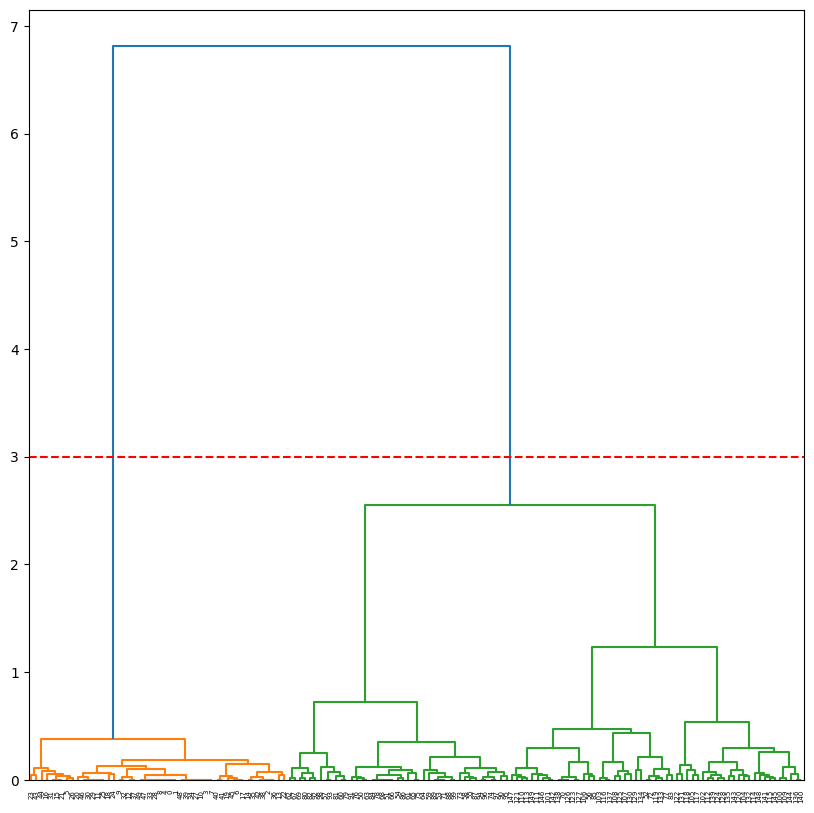

In [27]:
plt.figure(figsize = (10,10))
dendrogram = sch.dendrogram(sch.linkage(subset, method = 'ward') )
plt.axhline(y = 3, linestyle = '--', color = 'red')

so, total 2 cluster i.e. `k=2`


In [31]:
h_cluster = AgglomerativeClustering(n_clusters = 2, linkage='ward')
y_predicted = h_cluster.fit_predict(subset)

In [33]:
subset['cluster'] = y_predicted
subset.head()

C:\Users\sghor\AppData\Local\Temp\ipykernel_20884\2822925990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['cluster'] = y_predicted


,petal length (cm),petal width (cm),cluster
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1


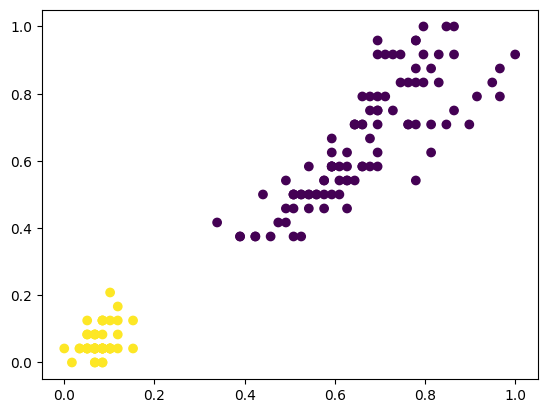

In [36]:
plt.scatter(subset.iloc[:,0], subset.iloc[:,1], c = subset.iloc[:,-1])